# Visualization Notebook
Reads saved CSVs from pipeline scripts 02, 08, 09.

In [4]:
# CELL 1: Setup

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.linalg import orthogonal_procrustes

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE = Path(processed_dir)
SEL_DIR = BASE / 'group_results' / 'selectivity'
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

COPE_SET = 'differential'  # Change as needed

CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L = '#7398af'
OTC_R = '#ee7183'
NONOT = '#FF9800'
CAT_COLORS = {'face': OTC_R, 'word': '#9C27B0', 'house': OTC_L, 'object': '#4CAF50'}
CAT_MARKERS = {'face': 'o', 'word': 's', 'house': '^', 'object': 'D'}
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL = ['object', 'house']
REORG = {'left': 'word', 'right': 'face'}

plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

RNG = np.random.default_rng(42)


def short_name(code):
    return code.replace('OTC', '').replace('nonOTC', 'n').replace('control', 'c')

print(f'Setup complete. COPE_SET={COPE_SET}')

Setup complete. COPE_SET=differential


In [32]:
# %%
# FIGURE 1: SELECTIVITY — Sum Selectivity Norm (Ayzenberg)

def fig_selectivity(metric='sum_selec_norm'):
    """Violin + jitter: selectivity per category, Controls L/R vs OTC-left/right, patients labeled."""
    sel_file = SEL_DIR / 'selectivity_summary.csv'
    if not sel_file.exists():
        print(f'  SKIP: {sel_file} not found')
        return

    df = pd.read_csv(sel_file)

    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False) # use True for shared y-axis across categories

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][metric].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][metric].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                      color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)
        
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd[metric].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                sub_short = row['sub'].replace('sub-', '')
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{sub_short}{star}', (pos + jit, row[metric]),
                           fontsize=7, fontweight='bold', ha='center', va='center',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                    edgecolor=color, alpha=0.85, linewidth=0.8),
                           zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                           color='black', marker='s', markersize=6,
                           markerfacecolor=color, markeredgecolor='black',
                           markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)             

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            label_map = {'sum_selec_norm': 'Summed Selectivity\n(normalized)',
                        'mean_act': 'Mean Activation (z)'}
            ax.set_ylabel(label_map.get(metric, metric))

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L, alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    title_map = {'sum_selec_norm': 'Summed Selectivity (Normalized)',
                 'mean_act': 'Mean Activation'}
    plt.suptitle(title_map.get(metric, metric), fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_selectivity_{metric}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_selectivity_{metric}.png')


def fig_selectivity_free(metric='sum_selec_norm'):
    """Same but independent y-scales per category."""
    sel_file = SEL_DIR / 'selectivity_summary.csv'
    if not sel_file.exists():
        print(f'  SKIP: {sel_file} not found')
        return

    df = pd.read_csv(sel_file)

    df['ses_int'] = df['ses'].astype(int)
    first = df.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][metric].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][metric].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                      color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd[metric].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.12, 0.12)
                sub_short = row['sub'].replace('sub-', '')
                star = '*' if REORG.get(side) == cat else ''
                ax.scatter(pos + jit, row[metric],
                          color=color, s=40, zorder=3, edgecolors='black',
                          linewidth=0.5, alpha=0.8)
                ax.annotate(f'{sub_short}{star}', (pos + jit, row[metric]),
                           fontsize=7, fontweight='bold', ha='center', va='bottom',
                           xytext=(0, 5), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                    edgecolor=color, alpha=0.85, linewidth=0.8))

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                           color='black', marker='s', markersize=6,
                           markerfacecolor=color, markeredgecolor='black',
                           markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        ax.set_ylabel('Summed Selectivity\n(normalized)' if metric == 'sum_selec_norm' else 'Mean Activation (z)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L, alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    title_map = {'sum_selec_norm': 'Summed Selectivity (Independent Scales)',
                 'mean_act': 'Mean Activation (Independent Scales)'}
    plt.suptitle(title_map.get(metric, metric), fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_selectivity_{metric}_free.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_selectivity_{metric}_free.png')

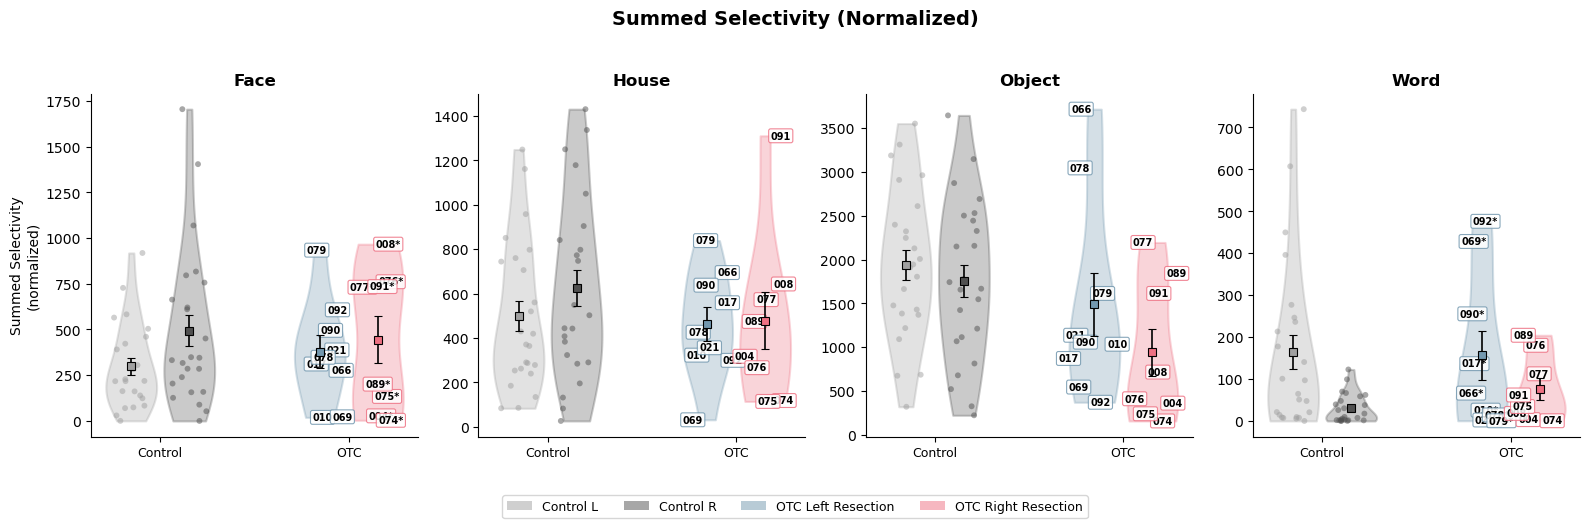

  Saved: fig_selectivity_sum_selec_norm.png


In [33]:
# Run: Summed Selectivity
fig_selectivity('sum_selec_norm')

In [37]:
def fig_liu_distinctiveness(cope_set='differential'):
    """Violin + jitter: Liu distinctiveness per category, Controls L/R vs OTC-left/right, patients labeled."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return

    df = pd.read_csv(liu_file)

    # First session per subject
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    cross = df[df['session'] == df['fs']]

    ctrl = cross[cross['status'] == 'control'].copy()
    otc  = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'intact')].copy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)  # use True for shared y-axis

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        # ── Controls: split left / right hemisphere ──────────────────────────
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['liu_distinctiveness'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['liu_distinctiveness'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── OTC patients: labeled badges ──────────────────────────────────────
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['liu_distinctiveness'].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── Violins ───────────────────────────────────────────────────────────
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'Liu Distinctiveness ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_liu_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_{cope_set}.png')

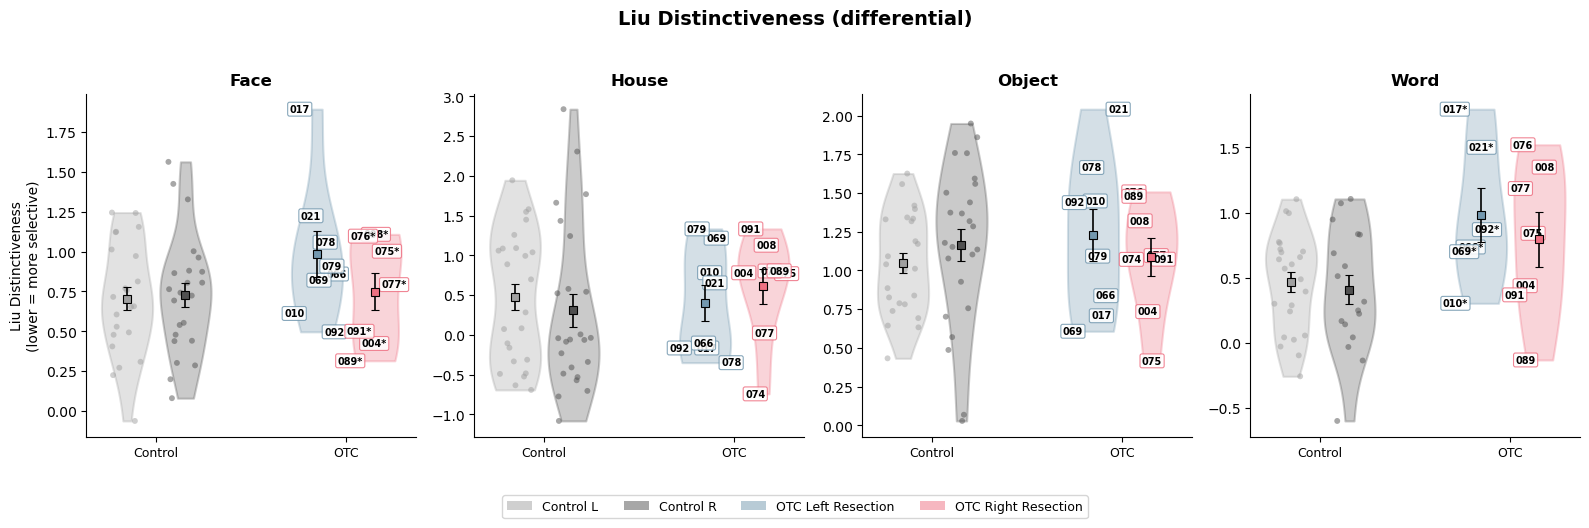

  Saved: fig_liu_differential.png


In [38]:
# Run: Liu Distinctiveness
fig_liu_distinctiveness(COPE_SET)

In [8]:
# FIGURE 3: PAIRWISE HEATMAPS — Controls vs OTC-left vs OTC-right
def fig_pairwise_heatmaps(cope_set='differential', roi_type='unilateral', alpha=0.05):
    """3-panel heatmap of pairwise Fisher-z pattern correlations (intact hemi only for OTC).
    Significance vs controls via Mann-Whitney U, BH-FDR corrected per OTC panel."""
    from scipy import stats

    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return

    df = pd.read_csv(pair_file)

    # First session per subject
    first = df.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]

    # Assign plot group; restrict OTC to intact hemisphere only
    df['plot_group'] = df.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'], axis=1)
    uni = df[df['cat_type'] == roi_type].copy()
    uni = uni[~((uni['group'] == 'OTC') & (uni['hemi_label'] != 'intact'))]

    cats = ['face', 'word', 'house', 'object']

    def get_vals(subset, ci, cj):
        for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
            v = subset[subset['pair'] == pair_str]['fisher_r'].values
            if len(v) > 0:
                return v
        return np.array([])

    def bh_fdr(pvals, alpha=0.05):
        """Benjamini-Hochberg FDR correction. Returns boolean array of rejected nulls."""
        pvals = np.asarray(pvals)
        n = len(pvals)
        order = np.argsort(pvals)
        ranked = np.empty(n, dtype=float)
        ranked[order] = np.arange(1, n + 1)
        threshold = (ranked / n) * alpha
        # All hypotheses up to the largest k where p <= threshold are rejected
        below = pvals <= threshold
        if not below.any():
            return np.zeros(n, dtype=bool)
        max_k = np.where(below)[0][np.argmax(np.where(below)[0])]  # largest index in sorted order
        cutoff = pvals[order[max_k]]
        return pvals <= cutoff

    ctrl_data = uni[uni['plot_group'] == 'control']

    # ── Layout: 3 panels + manual colorbar axis ──────────────────────────────
    fig = plt.figure(figsize=(17, 5))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.25)
    axes = [fig.add_subplot(gs[i]) for i in range(3)]
    cbar_ax = fig.add_subplot(gs[3])

    groups = [
        ('control',   'Controls'),
        ('OTC-left',  'Left Resection\n(Word* → Right Hemi)'),
        ('OTC-right', 'Right Resection\n(Face* → Left Hemi)'),
    ]

    im_ref = None
    for ax_idx, (grp, title) in enumerate(groups):
        ax = axes[ax_idx]
        gd = uni[uni['plot_group'] == grp]

        mat = np.full((4, 4), np.nan)
        raw_p = {}  # (i,j) → p-value, for off-diagonal OTC cells only

        # Collect means and raw p-values
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    continue
                vals = get_vals(gd, ci, cj)
                if len(vals) == 0:
                    continue
                mat[i, j] = vals.mean()
                if grp != 'control':
                    ctrl_vals = get_vals(ctrl_data, ci, cj)
                    if len(ctrl_vals) >= 2 and len(vals) >= 2:
                        _, p = stats.mannwhitneyu(vals, ctrl_vals, alternative='two-sided')
                        raw_p[(i, j)] = p

        # BH-FDR across all 12 off-diagonal cells for this OTC panel
        sig = np.full((4, 4), False)
        if raw_p:
            keys = list(raw_p.keys())
            pvals = np.array([raw_p[k] for k in keys])
            rejected = bh_fdr(pvals, alpha=alpha)
            for k, rej in zip(keys, rejected):
                sig[k] = rej

        im = ax.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        if im_ref is None:
            im_ref = im

        ax.set_xticks(range(4))
        ax.set_xticklabels([c.title() for c in cats], fontsize=10)
        ax.set_yticks(range(4))
        ax.set_yticklabels([c.title() for c in cats] if ax_idx == 0 else [], fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')

        for i in range(4):
            for j in range(4):
                if np.isnan(mat[i, j]):
                    continue
                txt_color = 'white' if mat[i, j] > 1.0 else 'black'
                label_txt = f'{mat[i,j]:.2f}{"*" if sig[i,j] else ""}'
                ax.text(j, i, label_txt, ha='center', va='center',
                        fontsize=9, color=txt_color, fontweight='bold')
                if sig[i, j]:
                    rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                         fill=False, edgecolor='black',
                                         linewidth=2.5, zorder=5)
                    ax.add_patch(rect)

    fig.colorbar(im_ref, cax=cbar_ax,
                 label='Fisher-z (voxelwise pattern similarity)\nhigher = less distinct')

    fig.text(0.5, -0.03,
             f'* p < {alpha}, BH-FDR corrected (12 pairs per panel, Mann–Whitney U two-sided); '
             f'OTC: intact hemisphere only',
             ha='center', fontsize=9, style='italic')

    plt.suptitle(f'Pairwise Pattern Similarity — {roi_type.title()} ROIs ({cope_set})',
                 fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_heatmap_{roi_type}_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_heatmap_{roi_type}_{cope_set}.png')

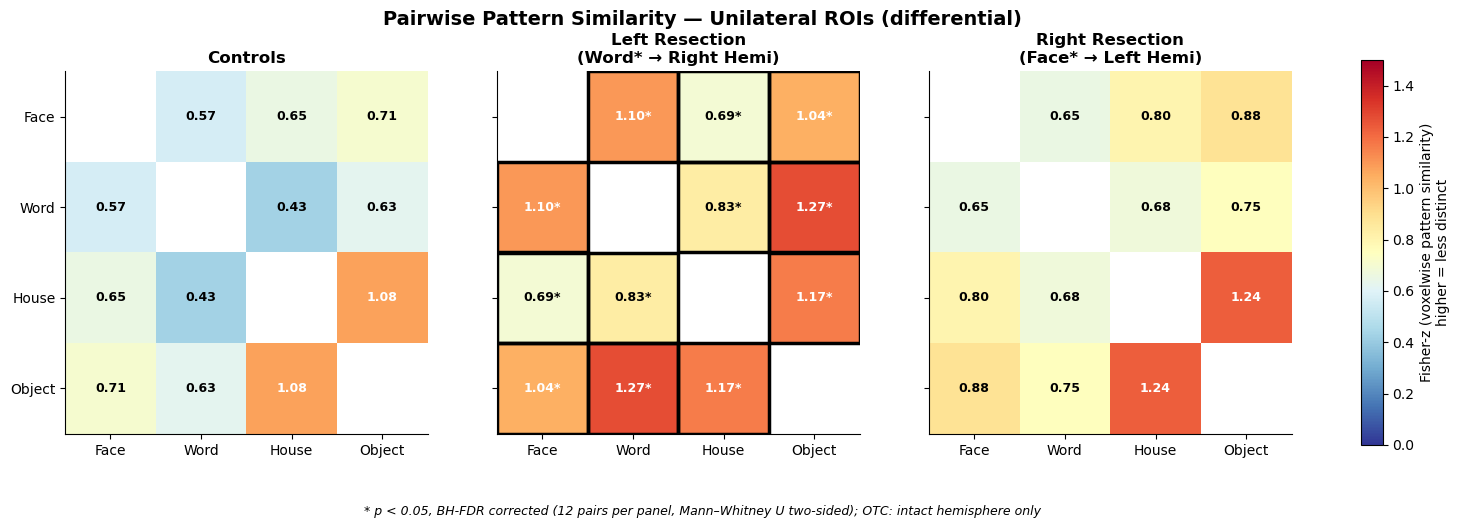

  Saved: fig_heatmap_unilateral_differential.png


In [9]:
# Run: Pairwise Heatmaps
fig_pairwise_heatmaps(COPE_SET, 'unilateral')

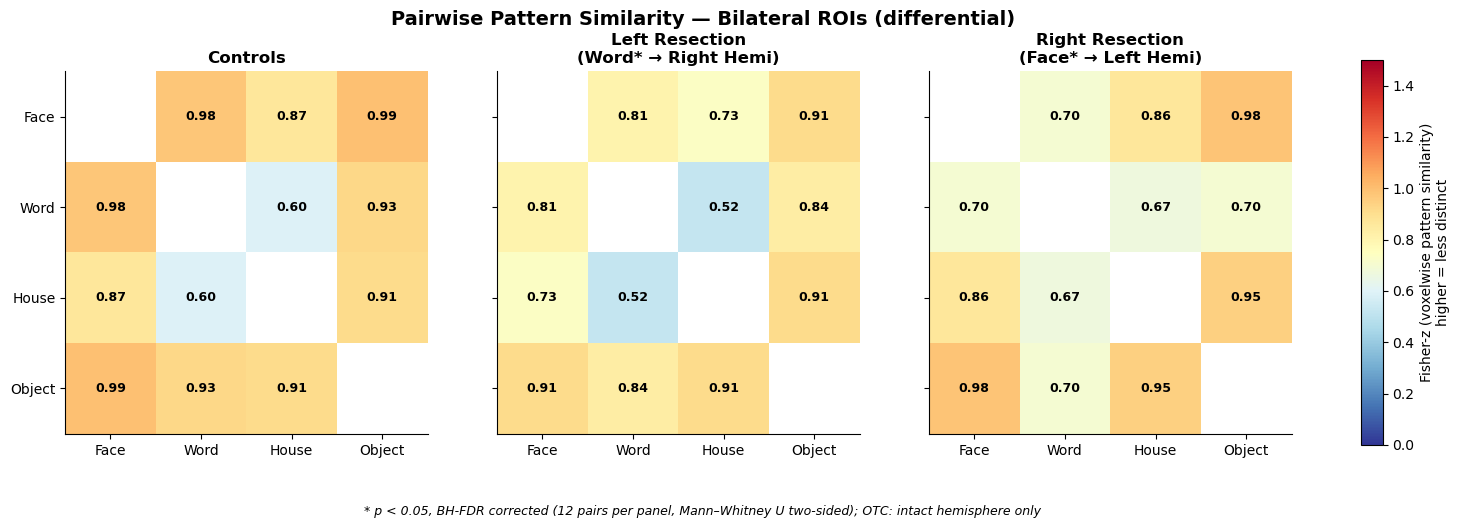

  Saved: fig_heatmap_bilateral_differential.png


In [10]:
fig_pairwise_heatmaps(COPE_SET, 'bilateral')

In [16]:
def fig_geometry(cope_set='differential'):
    """Violin + jitter: geometry preservation per category, Controls L/R vs OTC-left/right, patients labeled."""
    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not geo_file.exists():
        print(f'  SKIP: {geo_file} not found')
        return

    df = pd.read_csv(geo_file)

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)  # use True for shared y-axis

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        # ── Controls: split left / right hemisphere ───────────────────────────
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['geometry_preservation'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['geometry_preservation'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── OTC patients: labeled badges ──────────────────────────────────────
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['geometry_preservation'].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['geometry_preservation']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── Violins ───────────────────────────────────────────────────────────
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Geometry Preservation (r)\n(higher = more stable)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'Geometry Preservation ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_geometry_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_geometry_{cope_set}.png')

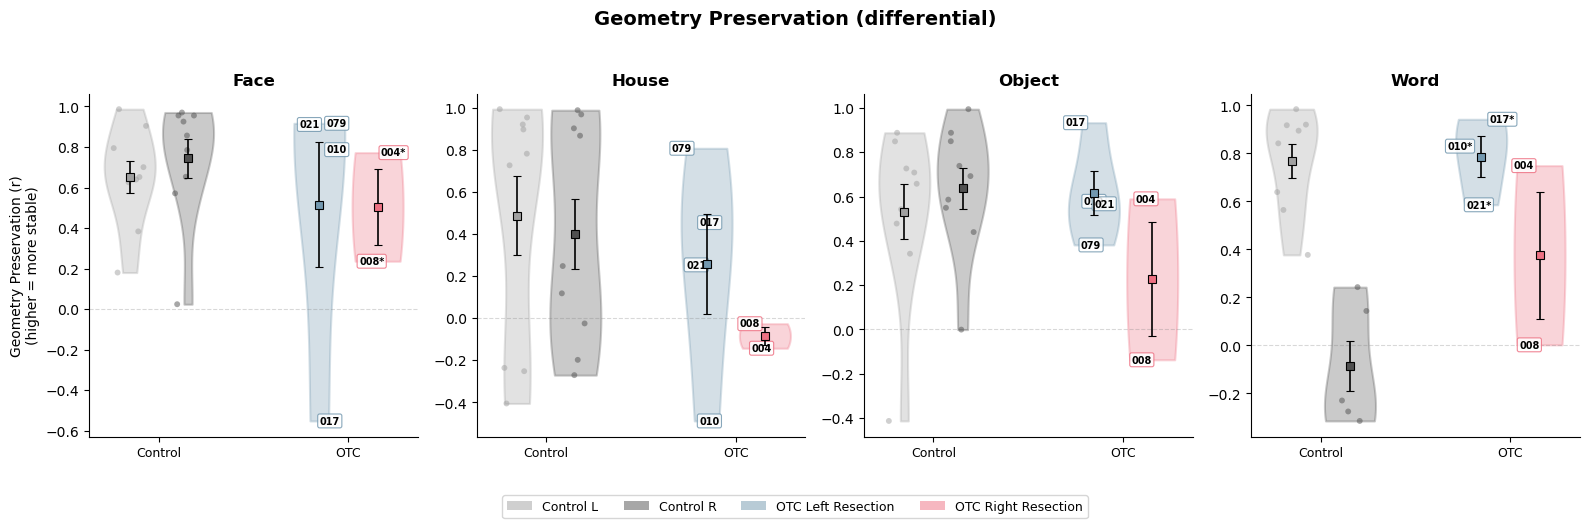

  Saved: fig_geometry_differential.png


In [17]:
# Run: Geometry Preservation
fig_geometry(COPE_SET)

In [18]:
# FIGURE 5: SPATIAL RELOCATION — Per category, patients labeled
def fig_spatial(cope_set='differential'):
    """Violin + jitter: spatial relocation per category, Controls L/R vs OTC-left/right, patients labeled."""
    sp_file = GEO_DIR / f'spatial_{cope_set}.csv'
    if not sp_file.exists():
        print(f'  SKIP: {sp_file} not found')
        return

    df = pd.read_csv(sp_file)

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)  # use True for shared y-axis

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        # ── Controls: split left / right hemisphere ───────────────────────────
        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'left')]['relocation_mm'].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi_label'] == 'right')]['relocation_mm'].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── OTC patients: labeled badges ──────────────────────────────────────
        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['relocation_mm'].values

            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)

            for _, row in sd.iterrows():
                jit = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['subject'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row['relocation_mm']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)

            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        # ── Violins ───────────────────────────────────────────────────────────
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i])
                body.set_alpha(0.3)
                body.set_edgecolor(vc[i])
                body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Centroid Displacement (mm)')

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'Spatial Relocation ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_spatial_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_spatial_{cope_set}.png')

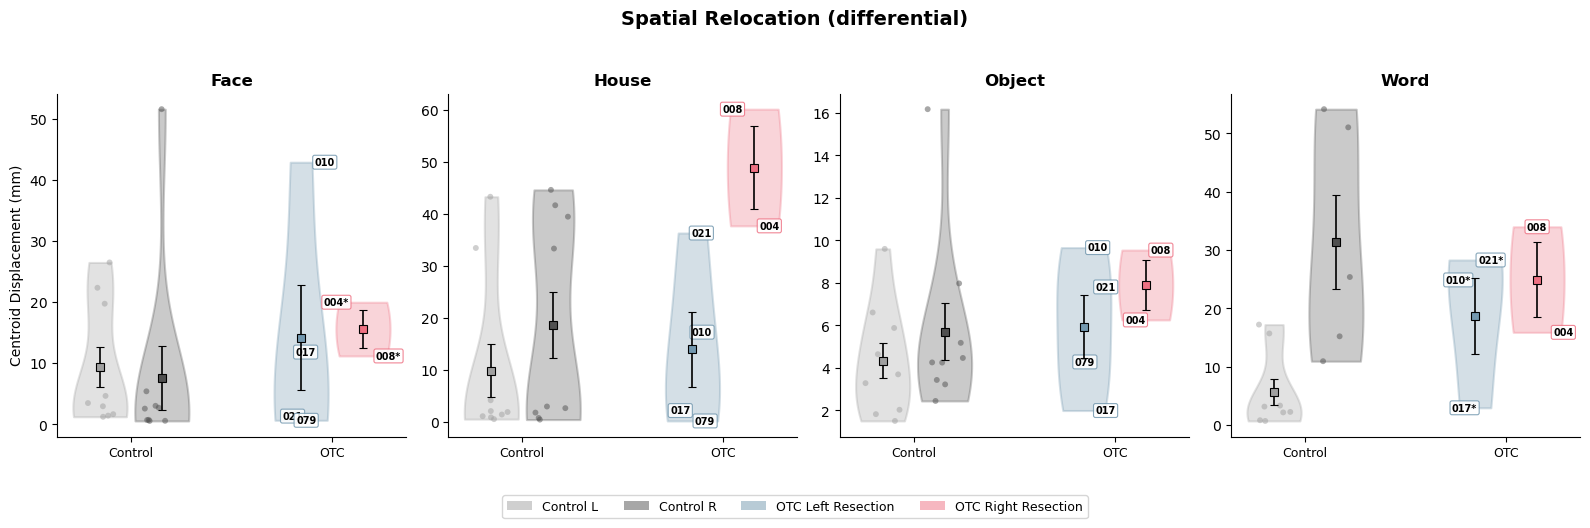

  Saved: fig_spatial_differential.png


In [19]:
# Run: Spatial Relocation
fig_spatial(COPE_SET)

In [15]:
# FIGURE 6: MDS PLOTS — Per patient, shift per category

def fig_mds_patients(cope_set='differential'):
    """Per-patient MDS: T1 and T2 category embeddings overlaid."""
    mds_file = GEO_DIR / f'mds_{cope_set}.csv'
    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not mds_file.exists():
        print(f'  SKIP: {mds_file} not found')
        return

    mds_df = pd.read_csv(mds_file)
    # MDS file has shift per measured category but not the actual coordinates
    # We need to recompute MDS from the geometry pipeline's RDMs
    # For now, use the shift values as a bar chart per patient

    otc = mds_df[mds_df['group'] == 'OTC']
    patients = sorted(otc['subject'].unique())
    n = len(patients)
    if n == 0:
        print('  No OTC patients with MDS data')
        return

    cols = min(n, 3)
    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(5*cols, 4*rows_n), squeeze=False)

    for idx, patient in enumerate(patients):
        ax = axes[idx // cols][idx % cols]
        pd_data = otc[otc['subject'] == patient]
        side = pd_data['surgery_side'].iloc[0]

        cats_present = []
        shifts = []
        colors = []
        for cat in CATEGORIES:
            cd = pd_data[pd_data['measured_category'] == cat]
            if len(cd) > 0:
                val = cd['mds_shift'].mean()
                cats_present.append(cat)
                shifts.append(val)
                colors.append(CAT_COLORS[cat])

        x = np.arange(len(cats_present))
        bars = ax.bar(x, shifts, color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)

        # Asterisk for reorganized
        for i, cat in enumerate(cats_present):
            if REORG.get(side) == cat:
                ax.text(i, shifts[i] + 0.005, '*', ha='center', fontsize=14, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels([c.title() for c in cats_present], fontsize=9)
        short = short_name(patient)
        ax.set_title(f'{short} ({side} resection)', fontsize=11, fontweight='bold')
        ax.set_ylabel('MDS Shift', fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for idx in range(n, rows_n * cols):
        axes[idx // cols][idx % cols].set_visible(False)

    plt.suptitle(f'MDS Embedding Shift Per Category ({cope_set})',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_mds_patients_{cope_set}.png'),
               dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_mds_patients_{cope_set}.png')



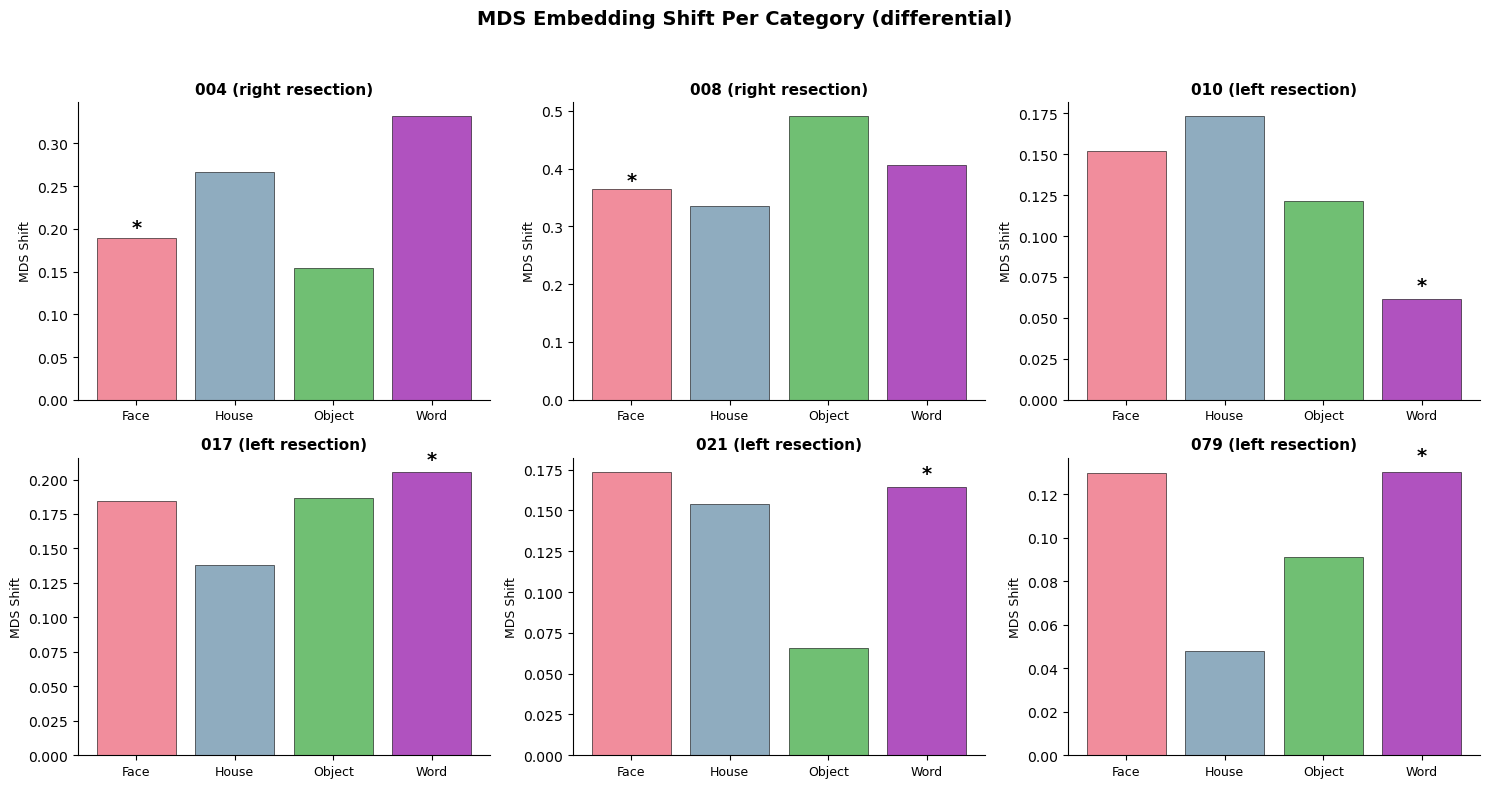

  Saved: fig_mds_patients_differential.png


In [40]:
fig_mds_patients(COPE_SET)

In [16]:
# FIGURE 7: PATIENT PROFILES — Relocation vs Geometry scatter
# ══════════════════════════════════════════════════════════════════════════════

def fig_patient_profiles(cope_set='differential'):
    """Per-patient scatter: relocation vs geometry for each category."""
    sp_file = GEO_DIR / f'spatial_{cope_set}.csv'
    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not sp_file.exists() or not geo_file.exists():
        print(f'  SKIP: files not found')
        return

    spatial = pd.read_csv(sp_file)
    geom = pd.read_csv(geo_file)

    merged = spatial.merge(geom,
                          on=['subject_id', 'hemi', 'category', 'group', 'cat_type',
                              'surgery_side', 'status', 'subject', 'cope_set'],
                          suffixes=('_sp', '_gm'))

    otc = merged[merged['group'] == 'OTC']
    patients = sorted(otc['subject'].unique())
    n = len(patients)
    if n == 0:
        return

    cols = min(n, 3)
    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(5*cols, 4.5*rows_n), squeeze=False)

    for idx, patient in enumerate(patients):
        ax = axes[idx // cols][idx % cols]
        pd_data = otc[otc['subject'] == patient]
        side = pd_data['surgery_side'].iloc[0]

        for _, row in pd_data.iterrows():
            cat = row['category']
            star = '*' if REORG.get(side) == cat else ''
            ax.scatter(row['relocation_mm'], row['geometry_preservation'],
                      c=CAT_COLORS[cat], marker=CAT_MARKERS[cat],
                      s=120, edgecolors='black', linewidth=0.8, zorder=5)
            ax.annotate(f'{cat.title()}{star}',
                       (row['relocation_mm'], row['geometry_preservation']),
                       fontsize=8, ha='left', va='bottom',
                       xytext=(4, 4), textcoords='offset points')

        short = short_name(patient)
        ax.set_title(f'{short} ({side} resection)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Relocation (mm)', fontsize=9)
        ax.set_ylabel('Geometry Pres. (r)', fontsize=9)
        ax.set_ylim(-0.7, 1.1)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)

    for idx in range(n, rows_n * cols):
        axes[idx // cols][idx % cols].set_visible(False)

    handles = [Line2D([0], [0], marker=CAT_MARKERS[c], color=CAT_COLORS[c],
               linestyle='None', markersize=8, markeredgecolor='black',
               markeredgewidth=0.8, label=c.title()) for c in CATEGORIES]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
              frameon=True, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle(f'Individual OTC Profiles ({cope_set})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(str(FIG_DIR / f'fig_profiles_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_profiles_{cope_set}.png')

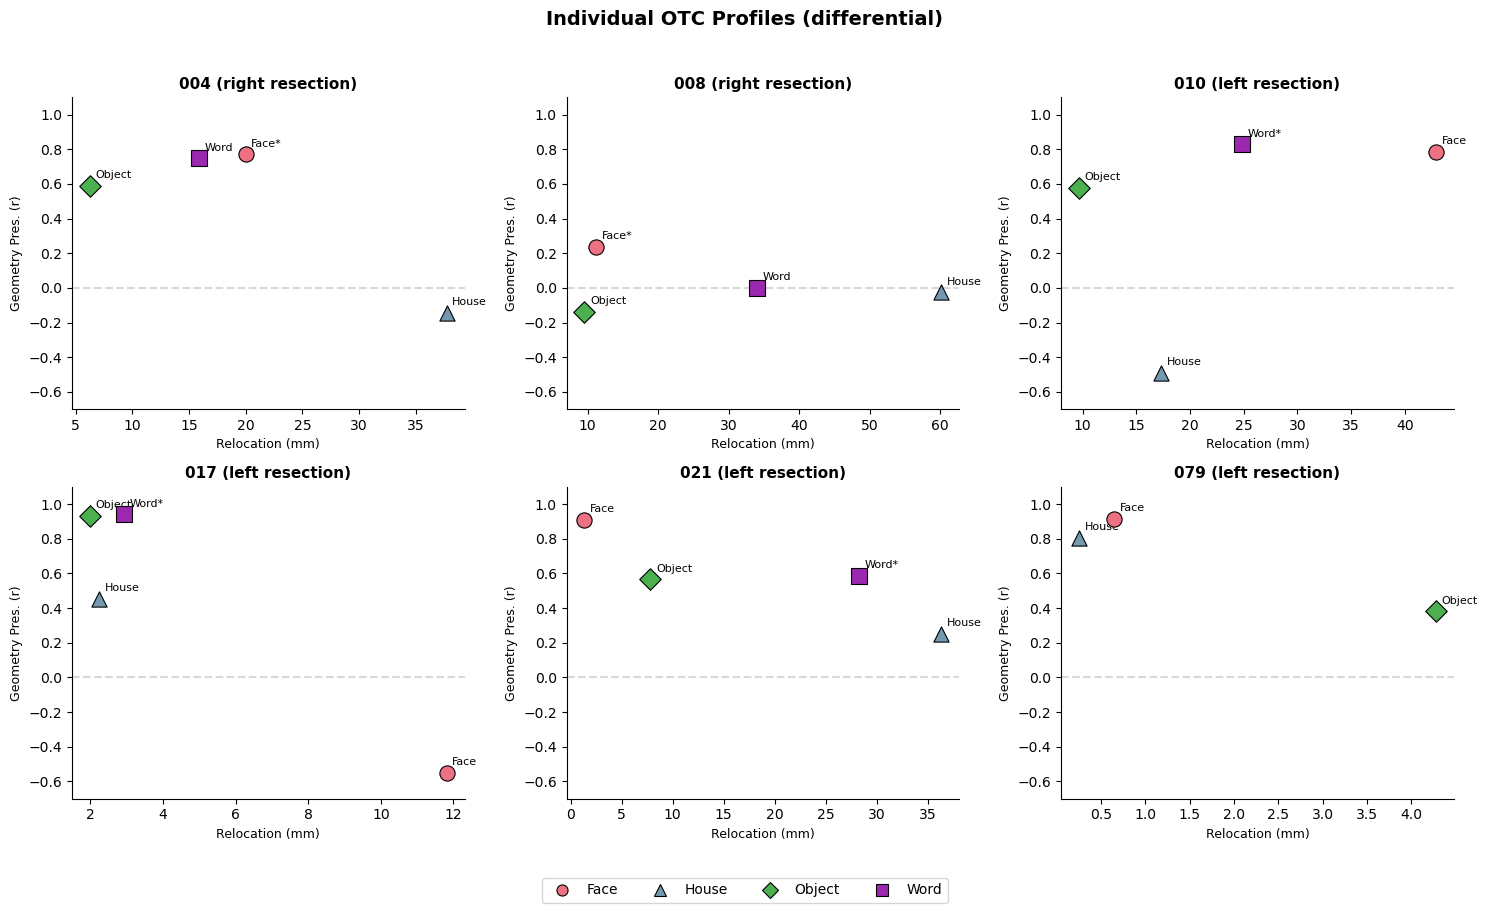

  Saved: fig_profiles_differential.png


In [39]:
fig_patient_profiles(COPE_SET)

In [18]:
# %%
# PUBLICATION RESULTS TABLE

from scipy.stats import mannwhitneyu, spearmanr
import statsmodels.formula.api as smf

def bootstrap_ci(data, n_boot=10000):
    rng = np.random.default_rng(42)
    means = [np.mean(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    return np.mean(data), np.percentile(means, 2.5), np.percentile(means, 97.5)

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na-1)*np.std(a,ddof=1)**2 + (nb-1)*np.std(b,ddof=1)**2) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else np.nan

def rank_biserial(u, n1, n2):
    return 1 - (2*u) / (n1*n2)

cope = COPE_SET

# ══════════════════════════════════════════════════════════════════════════
# TABLE 1: Liu Distinctiveness — Cross-sectional OTC vs Controls
# ══════════════════════════════════════════════════════════════════════════

print("=" * 100)
print("TABLE 1: Liu Distinctiveness — Cross-Sectional (First Post-Surgery Session)")
print(f"Cope set: {cope}")
print("=" * 100)
print("Higher = less distinct (worse). * = reorganized category.")
print()

liu_file = LIU_DIR / f'liu_distinctiveness_{cope}.csv'
if liu_file.exists():
    liu = pd.read_csv(liu_file)
    first = liu.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    liu = liu.merge(first, on='subject_id')
    cross = liu[liu['session'] == liu['fs']]

    otc = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'intact')]
    ctrl = cross[cross['status'] == 'control']

    # OLS per category
    print(f"{'Category':<10} {'OTC mean':<12} {'OTC 95% CI':<22} {'Ctrl mean':<12} "
          f"{'Ctrl 95% CI':<22} {'β(OTC)':<10} {'SE':<8} {'p':<10} {'d':<8} {'R²'}")
    print("-" * 120)

    for cat in CATEGORIES:
        otc_vals = otc[otc['category'] == cat]['liu_distinctiveness'].values
        ctrl_vals = ctrl[ctrl['category'] == cat]['liu_distinctiveness'].values

        if len(otc_vals) < 2 or len(ctrl_vals) < 2:
            continue

        om, olo, ohi = bootstrap_ci(otc_vals)
        cm, clo, chi = bootstrap_ci(ctrl_vals)
        d = cohens_d(otc_vals, ctrl_vals)

        # OLS
        model_data = pd.DataFrame({
            'liu': np.concatenate([otc_vals, ctrl_vals]),
            'group': ['OTC']*len(otc_vals) + ['control']*len(ctrl_vals),
        })
        try:
            m = smf.ols('liu ~ C(group, Treatment("control"))', data=model_data).fit()
            gk = [k for k in m.params.index if 'OTC' in k][0]
            beta, se, p, r2 = m.params[gk], m.bse[gk], m.pvalues[gk], m.rsquared
        except:
            beta, se, p, r2 = np.nan, np.nan, np.nan, np.nan

        star = " " 
        print(f"{cat:<10} {om:<12.3f} [{olo:.3f}, {ohi:.3f}]    {cm:<12.3f} "
              f"[{clo:.3f}, {chi:.3f}]    {beta:<10.3f} {se:<8.3f} {p:<10.4f} {d:<8.2f} {r2:.3f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 2: Liu Distinctiveness — By Surgery Side
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 2: Liu Distinctiveness — OTC by Surgery Side vs Controls")
print("=" * 100)
print()

if liu_file.exists():
    otc['surgery_side_label'] = otc['subject_id'].map(
        lambda s: cross[cross['subject_id']==s]['surgery_side'].iloc[0] 
        if s in cross['subject_id'].values else 'na')

    print(f"{'Category':<10} {'Side':<8} {'OTC mean':<12} {'OTC 95% CI':<22} "
          f"{'Ctrl mean':<12} {'U':<10} {'p':<10} {'r_rb':<8} {'d'}")
    print("-" * 100)

    for cat in CATEGORIES:
        ctrl_vals = ctrl[ctrl['category'] == cat]['liu_distinctiveness'].values
        if len(ctrl_vals) < 2:
            continue
        cm, _, _ = bootstrap_ci(ctrl_vals)

        for side in ['left', 'right']:
            otc_side = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            ov = otc_side['liu_distinctiveness'].values
            if len(ov) < 2:
                continue

            om, olo, ohi = bootstrap_ci(ov)
            u, p = mannwhitneyu(ov, ctrl_vals, alternative='greater')
            rb = rank_biserial(u, len(ov), len(ctrl_vals))
            d = cohens_d(ov, ctrl_vals)
            star = "*" if REORG.get(side) == cat else " "

            print(f"{cat}{star:<9} {side:<8} {om:<12.3f} [{olo:.3f}, {ohi:.3f}]    "
                  f"{cm:<12.3f} {u:<10.0f} {p:<10.4f} {rb:<8.2f} {d:.2f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 3: Pairwise Correlations — Unilateral ROIs
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 3: Pairwise Category Correlations in Unilateral ROIs")
print("=" * 100)
print()

pair_file = LIU_DIR / f'pairwise_correlations_{cope}.csv'
if pair_file.exists():
    pdf = pd.read_csv(pair_file)
    first = pdf.groupby('subject_id')['session'].min().reset_index().rename(columns={'session': 'fs'})
    pdf = pdf.merge(first, on='subject_id')
    pdf = pdf[pdf['session'] == pdf['fs']]
    pdf['plot_group'] = pdf.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'], axis=1)
    uni = pdf[pdf['cat_type'] == 'unilateral']

    pairs = ['face-word', 'face-house', 'face-object', 'word-house', 'word-object', 'house-object']

    print(f"{'Pair':<15} {'Group':<12} {'Mean':<10} {'95% CI':<22} "
          f"{'vs Ctrl U':<12} {'p':<10} {'r_rb':<8} {'d'}")
    print("-" * 100)

    for pair in pairs:
        ctrl_p = uni[(uni['plot_group'] == 'control') & (uni['pair'] == pair)]['fisher_r']
        if len(ctrl_p) == 0:
            # Try reversed
            parts = pair.split('-')
            ctrl_p = uni[(uni['plot_group'] == 'control') & (uni['pair'] == f'{parts[1]}-{parts[0]}')]['fisher_r']

        ctrl_vals = ctrl_p.values
        if len(ctrl_vals) < 2:
            continue
        cm, clo, chi = bootstrap_ci(ctrl_vals)
        print(f"{pair:<15} {'control':<12} {cm:<10.3f} [{clo:.3f}, {chi:.3f}]")

        for grp in ['OTC-left', 'OTC-right']:
            gp = uni[(uni['plot_group'] == grp) & (uni['pair'] == pair)]['fisher_r']
            if len(gp) == 0:
                parts = pair.split('-')
                gp = uni[(uni['plot_group'] == grp) & (uni['pair'] == f'{parts[1]}-{parts[0]}')]['fisher_r']
            gv = gp.values
            if len(gv) < 2:
                continue

            gm, glo, ghi = bootstrap_ci(gv)
            u, p = mannwhitneyu(gv, ctrl_vals, alternative='greater')
            rb = rank_biserial(u, len(gv), len(ctrl_vals))
            d = cohens_d(gv, ctrl_vals)
            print(f"{'':15} {grp:<12} {gm:<10.3f} [{glo:.3f}, {ghi:.3f}]    "
                  f"{u:<12.0f} {p:<10.4f} {rb:<8.2f} {d:.2f}")
        print()

# ══════════════════════════════════════════════════════════════════════════
# TABLE 4: Geometry Preservation — Per Category
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 4: Geometry Preservation — Per Category (Longitudinal Subjects)")
print(f"Cope set: {cope}")
print("=" * 100)
print("Higher = more stable. * = reorganized category.")
print()

geo_file = GEO_DIR / f'geometry_{cope}.csv'
if geo_file.exists():
    gdf = pd.read_csv(geo_file)
    otc_g = gdf[gdf['group'] == 'OTC']
    ctrl_g = gdf[gdf['group'] == 'control']

    print(f"{'Category':<10} {'OTC mean':<12} {'OTC 95% CI':<22} {'n':<5} "
          f"{'Ctrl mean':<12} {'Ctrl 95% CI':<22} {'n':<5} {'U':<10} {'p':<10} {'r_rb':<8} {'d'}")
    print("-" * 125)

    for cat in CATEGORIES:
        ov = otc_g[otc_g['category'] == cat]['geometry_preservation'].values
        cv = ctrl_g[ctrl_g['category'] == cat]['geometry_preservation'].values

        if len(ov) < 2 or len(cv) < 2:
            continue

        om, olo, ohi = bootstrap_ci(ov)
        cm, clo, chi = bootstrap_ci(cv)
        u, p = mannwhitneyu(ov, cv, alternative='less')
        rb = rank_biserial(u, len(ov), len(cv))
        d = cohens_d(ov, cv)

        print(f"{cat:<10} {om:<12.3f} [{olo:.3f}, {ohi:.3f}]    {len(ov):<5} "
              f"{cm:<12.3f} [{clo:.3f}, {chi:.3f}]    {len(cv):<5} "
              f"{u:<10.0f} {p:<10.4f} {rb:<8.2f} {d:.2f}")

    # By surgery side
    print(f"\nOTC by surgery side:")
    print(f"{'Category':<10} {'Side':<8} {'Mean':<10} {'95% CI':<22} {'n'}")
    print("-" * 60)
    for cat in CATEGORIES:
        for side in ['left', 'right']:
            sv = otc_g[(otc_g['category'] == cat) & (otc_g['surgery_side'] == side)]
            vals = sv['geometry_preservation'].values
            star = "*" if REORG.get(side) == cat else " "
            if len(vals) >= 2:
                m, lo, hi = bootstrap_ci(vals)
                print(f"{cat}{star:<9} {side:<8} {m:<10.3f} [{lo:.3f}, {hi:.3f}]    {len(vals)}")
            elif len(vals) == 1:
                print(f"{cat}{star:<9} {side:<8} {vals[0]:<10.3f} [n=1]                {len(vals)}")

    # Reorganized vs typical
    print(f"\nReorganized vs Typical (unilateral ROIs):")
    reorg_v = otc_g[otc_g['roi_status'] == 'reorganized']['geometry_preservation'].values
    typ_v = otc_g[otc_g['roi_status'] == 'typical']['geometry_preservation'].values
    if len(reorg_v) >= 2 and len(typ_v) >= 2:
        rm, rlo, rhi = bootstrap_ci(reorg_v)
        tm, tlo, thi = bootstrap_ci(typ_v)
        u, p = mannwhitneyu(reorg_v, typ_v, alternative='greater')
        rb = rank_biserial(u, len(reorg_v), len(typ_v))
        d = cohens_d(reorg_v, typ_v)
        print(f"  Reorganized: {rm:.3f} [{rlo:.3f}, {rhi:.3f}] (n={len(reorg_v)})")
        print(f"  Typical:     {tm:.3f} [{tlo:.3f}, {thi:.3f}] (n={len(typ_v)})")
        print(f"  U={u:.0f}, p={p:.4f}, r_rb={rb:.2f}, d={d:.2f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 5: Spatial Relocation — Per Category
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 5: Spatial Relocation (mm) — Per Category")
print("=" * 100)
print()

sp_file = GEO_DIR / f'spatial_{cope}.csv'
if sp_file.exists():
    sdf = pd.read_csv(sp_file)
    otc_s = sdf[sdf['group'] == 'OTC']
    ctrl_s = sdf[sdf['group'] == 'control']

    print(f"{'Category':<10} {'OTC mean':<12} {'OTC 95% CI':<22} {'n':<5} "
          f"{'Ctrl mean':<12} {'Ctrl 95% CI':<22} {'n':<5} {'U':<10} {'p':<10} {'d'}")
    print("-" * 115)

    for cat in CATEGORIES:
        ov = otc_s[otc_s['category'] == cat]['relocation_mm'].values
        cv = ctrl_s[ctrl_s['category'] == cat]['relocation_mm'].values
        if len(ov) < 2 or len(cv) < 2:
            continue

        om, olo, ohi = bootstrap_ci(ov)
        cm, clo, chi = bootstrap_ci(cv)
        u, p = mannwhitneyu(ov, cv, alternative='greater')
        d = cohens_d(ov, cv)

        print(f"{cat:<10} {om:<12.1f} [{olo:.1f}, {ohi:.1f}]          {len(ov):<5} "
              f"{cm:<12.1f} [{clo:.1f}, {chi:.1f}]          {len(cv):<5} "
              f"{u:<10.0f} {p:<10.4f} {d:.2f}")

# ══════════════════════════════════════════════════════════════════════════
# TABLE 6: Longitudinal Liu Distinctiveness Change
# ══════════════════════════════════════════════════════════════════════════

print()
print("=" * 100)
print("TABLE 6: Longitudinal Change in Liu Distinctiveness (Final − Baseline)")
print("=" * 100)
print("Negative = becoming more selective over time.")
print()

if liu_file.exists():
    liu_full = pd.read_csv(liu_file)

    # Get subjects with 2+ post-surgery sessions, intact hemi
    long_rows = []
    for sid in liu_full['subject_id'].unique():
        sd = liu_full[liu_full['subject_id'] == sid]
        sessions = sorted(sd['session'].unique())
        if len(sessions) < 2:
            continue
        s1, s2 = sessions[0], sessions[-1]
        for cat in CATEGORIES:
            d1 = sd[(sd['session'] == s1) & (sd['category'] == cat) & 
                    (sd['hemi_label'].isin(['intact', 'left', 'right']))]
            d2 = sd[(sd['session'] == s2) & (sd['category'] == cat) & 
                    (sd['hemi_label'].isin(['intact', 'left', 'right']))]
            if len(d1) > 0 and len(d2) > 0:
                change = d2.iloc[0]['liu_distinctiveness'] - d1.iloc[0]['liu_distinctiveness']
                long_rows.append({
                    'subject': sd.iloc[0]['subject'],
                    'group': sd.iloc[0]['group'],
                    'category': cat,
                    'change': change,
                })

    long = pd.DataFrame(long_rows)

    if len(long) > 0:
        otc_l = long[long['group'] == 'OTC']
        ctrl_l = long[long['group'] == 'control']

        print(f"{'Category':<10} {'OTC Δ':<12} {'OTC 95% CI':<22} {'n':<5} "
              f"{'Ctrl Δ':<12} {'Ctrl 95% CI':<22} {'n':<5} {'β(OTC)':<10} {'p'}")
        print("-" * 105)

        for cat in CATEGORIES:
            ov = otc_l[otc_l['category'] == cat]['change'].values
            cv = ctrl_l[ctrl_l['category'] == cat]['change'].values
            if len(ov) < 2 or len(cv) < 2:
                continue

            om, olo, ohi = bootstrap_ci(ov)
            cm, clo, chi = bootstrap_ci(cv)

            model_data = pd.DataFrame({
                'change': np.concatenate([ov, cv]),
                'group': ['OTC']*len(ov) + ['control']*len(cv),
            })
            try:
                m = smf.ols('change ~ C(group, Treatment("control"))', data=model_data).fit()
                gk = [k for k in m.params.index if 'OTC' in k][0]
                beta, p = m.params[gk], m.pvalues[gk]
            except:
                beta, p = np.nan, np.nan

            print(f"{cat:<10} {om:<+12.3f} [{olo:+.3f}, {ohi:+.3f}]  {len(ov):<5} "
                  f"{cm:<+12.3f} [{clo:+.3f}, {chi:+.3f}]  {len(cv):<5} "
                  f"{beta:<+10.3f} {p:.4f}")

print()
print("=" * 100)
print("END OF RESULTS TABLES")
print("=" * 100)

TABLE 1: Liu Distinctiveness — Cross-Sectional (First Post-Surgery Session)
Cope set: differential
Higher = less distinct (worse). * = reorganized category.

Category   OTC mean     OTC 95% CI             Ctrl mean    Ctrl 95% CI            β(OTC)     SE       p          d        R²
------------------------------------------------------------------------------------------------------------------------
face       0.874        [0.689, 1.076]    0.716        [0.614, 0.822]    0.158      0.110    0.1550     0.43     0.034
house      0.507        [0.191, 0.803]    0.393        [0.138, 0.656]    0.115      0.253    0.6519     0.13     0.003
object     1.159        [0.957, 1.365]    1.105        [0.983, 1.225]    0.054      0.125    0.6700     0.12     0.003
word       0.883        [0.586, 1.186]    0.441        [0.313, 0.568]    0.442      0.145    0.0037     0.97     0.154

TABLE 2: Liu Distinctiveness — OTC by Surgery Side vs Controls

Category   Side     OTC mean     OTC 95% CI           

/tmp/ipykernel_3500705/803519258.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  otc['surgery_side_label'] = otc['subject_id'].map(


face          left     0.984        [0.737, 1.287]    0.716        253        0.0479     -0.38    0.72
face*         right    0.748        [0.519, 0.973]    0.716        171        0.4036     -0.06    0.09
house          left     0.401        [-0.029, 0.847]    0.393        199        0.4407     -0.04    0.01
house          right    0.613        [0.125, 0.994]    0.393        226        0.2200     -0.18    0.24
object          left     1.230        [0.915, 1.566]    1.105        219        0.2710     -0.14    0.28
object          right    1.087        [0.838, 1.316]    1.105        183        0.5864     0.05     -0.04
word*         left     0.984        [0.602, 1.393]    0.441        189        0.0113     -0.57    1.25
word          right    0.796        [0.373, 1.196]    0.441        194        0.0556     -0.39    0.80

TABLE 3: Pairwise Category Correlations in Unilateral ROIs

Pair            Group        Mean       95% CI                 vs Ctrl U    p          r_rb     d
---------

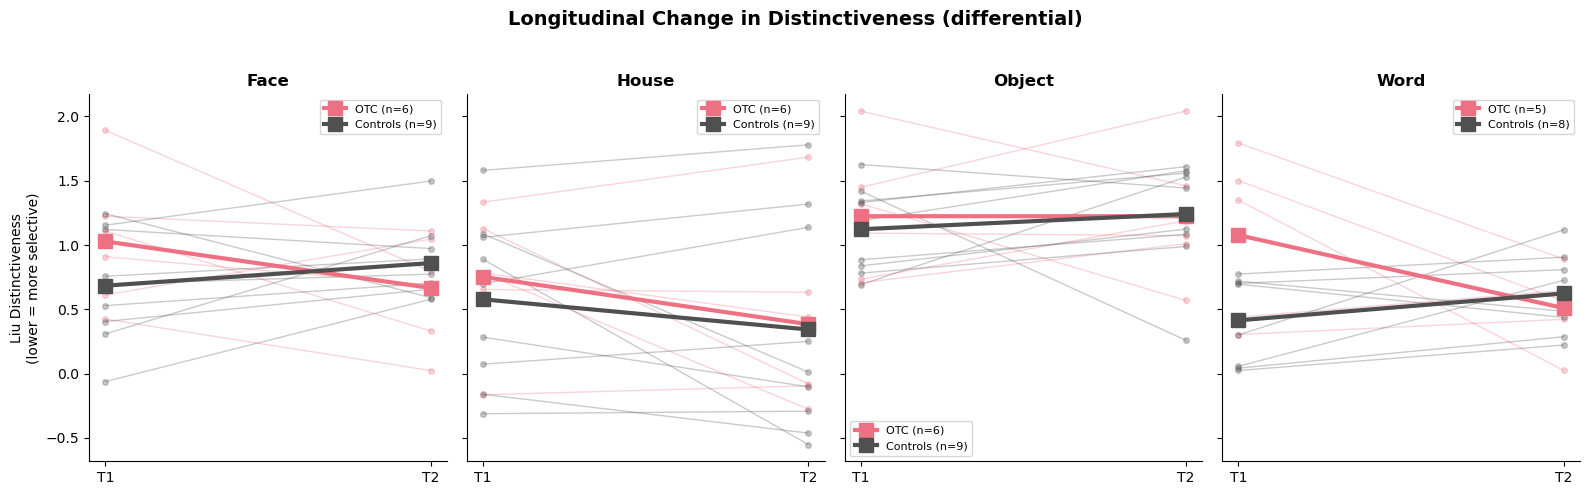

  Saved: fig_trajectories_differential.png
  MDS embedding plots for: ['OTC004', 'OTC008', 'OTC010', 'control018']
  NOTE: Requires recomputing from NIfTI data.
  For publication, run this in the geometry notebook where sphere/beta
  extraction functions are available, or save RDMs in script 09.
  Skipping automated plot — use individual notebook cells instead.


In [19]:
# %%
# FIGURE: Longitudinal Trajectories (T1 → T2 distinctiveness)

def fig_longitudinal_trajectories(cope_set='differential'):
    """Individual T1→T2 trajectories for OTC vs Controls, per category."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file}')
        return

    df = pd.read_csv(liu_file)
    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]

        for grp, color, label in [('OTC', OTC_R, 'OTC'), ('control', CTRL_R, 'Controls')]:
            t1_vals, t2_vals = [], []

            for sid in df['subject_id'].unique():
                sd = df[(df['subject_id'] == sid) & (df['group'] == grp) &
                        (df['category'] == cat) & (df['hemi_label'].isin(['intact', 'left', 'right']))]
                sessions = sorted(sd['session'].unique())
                if len(sessions) < 2:
                    continue

                v1 = sd[sd['session'] == sessions[0]]['liu_distinctiveness']
                v2 = sd[sd['session'] == sessions[-1]]['liu_distinctiveness']
                if len(v1) > 0 and len(v2) > 0:
                    y1, y2 = v1.values[0], v2.values[0]
                    ax.plot([0, 1], [y1, y2], '-o', color=color,
                           alpha=0.3, markersize=4, linewidth=1)
                    t1_vals.append(y1)
                    t2_vals.append(y2)

            if t1_vals:
                ax.plot([0, 1], [np.mean(t1_vals), np.mean(t2_vals)], '-s',
                       color=color, linewidth=3, markersize=10,
                       label=f'{label} (n={len(t1_vals)})', zorder=10)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['T1', 'T2'])
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
        ax.legend(fontsize=8)

    plt.suptitle(f'Longitudinal Change in Distinctiveness ({cope_set})',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_trajectories_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_trajectories_{cope_set}.png')

fig_longitudinal_trajectories(COPE_SET)

# %%
# FIGURE: MDS Embeddings T1 vs T2 (example patients + control)

def fig_mds_embeddings(cope_set='differential'):
    """Actual 2D MDS plots for select patients showing T1 and T2 overlaid."""
    from scipy.linalg import orthogonal_procrustes

    geo_file = GEO_DIR / f'geometry_{cope_set}.csv'
    if not geo_file.exists():
        print(f'  SKIP: {geo_file}')
        return

    # We need to recompute MDS from raw data since CSVs don't store coordinates
    # Read the geometry CSV to identify which patients to plot
    gdf = pd.read_csv(geo_file)
    otc_subs = sorted(gdf[gdf['group'] == 'OTC']['subject'].unique())
    ctrl_subs = sorted(gdf[gdf['group'] == 'control']['subject'].unique())

    # Pick up to 3 OTC + 1 control
    plot_subs = otc_subs[:3] + ctrl_subs[:1]
    n = len(plot_subs)

    print(f"  MDS embedding plots for: {plot_subs}")
    print(f"  NOTE: Requires recomputing from NIfTI data.")
    print(f"  For publication, run this in the geometry notebook where sphere/beta")
    print(f"  extraction functions are available, or save RDMs in script 09.")
    print(f"  Skipping automated plot — use individual notebook cells instead.")

fig_mds_embeddings(COPE_SET)